# 2. Tutorial 2

**Course:** Power Electronics Devices and Components  

## 2.1. Blocking-voltage versus drift-resistance design map

Build the trade-off map of a silicon power-diode drift region. Use a one-sided $p^+ - n^-$ structure.
Following constants are given:
- $\varepsilon_\mathrm{s} = 1.04 ~\mathrm{pF/cm}$
- $q = 1.6 \cdot 10^{-19}~\mathrm{C}$
- $\mu_\mathrm{n} = 1000~\mathrm{{cm}^2/Vs}$

The diagrams shall sweep $N_\mathrm{D}$ in range [$1 \cdot 10^{14} \ldots 5 \cdot 10^{15}~\mathrm{cm^{-3}}$]
and $t_\mathrm{d}$ in range [$20 \ldots 200~\mathrm{\mu m}$]

2.1.1 Import necessary modules (numpy as np and matplotlib.pyplot as plt) and add constant variables for the constant values.

2.1.2 Create a function with input parameter  $N_\mathrm{D}$ and $t_\mathrm{d}$, which calculates the punch-through-limited blocking voltage:
$$V_\mathrm{PT} = \frac{qN_\mathrm{D}t_\mathrm{d}^2}{2\varepsilon_\mathrm{s}}.$$

2.1.3 Create a function with input parameter  $N_\mathrm{D}$ and $t_\mathrm{d}$, which calculates the drift-region specific resistance proxy:
$$R_{\mathrm{drift}} \propto \frac{t_\mathrm{d}}{q\mu_\mathrm{n} N_\mathrm{D}}.$$

2.1.4 Plot $V_\mathrm{PT}$ versus $N_\mathrm{D}$ for 4 $t_\mathrm{d}$-values within the given range.

2.1.5 Plot $R_{\mathrm{drift}}$ versus $N_\mathrm{D}$ for the selected $t_\mathrm{d}$

2.1.6 Create a scatter plot of $V_\mathrm{PT}$ versus $R_{\mathrm{drift}}$


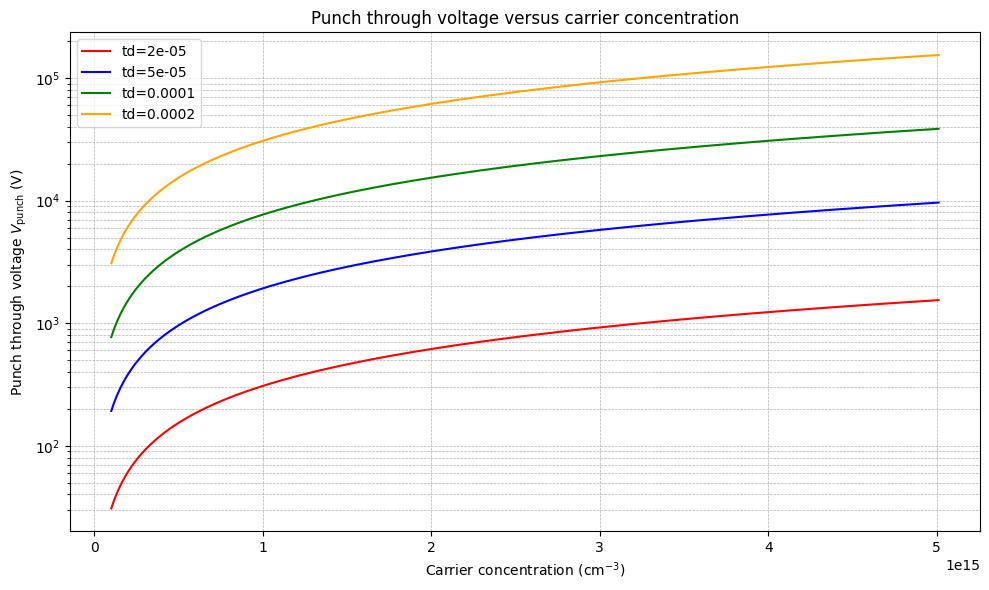

In [1]:
# Subtask 2.1.1 Import necessary modules (numpy as np and matplotlib.pyplot as plt) and add constant variables for the constant values.

import numpy as np
import matplotlib.pyplot as plt

# Create color list and marker list
color_list = ['red', 'blue', 'green', 'orange', 'black', 'cyan', 'magenta', 'purple']
marker_list=['.', '*', '+', '_', 'o', 's', 'D', '^', 'v', '<', '>', 'p', 'h', 'H', 'x', 'D', 'd', 'P', 'X']


# ---------------------------------------------------------------------
# Fixed constants for the tutorial
# ---------------------------------------------------------------------
eps_s = 104e-12          # 1.04e-12F/cm = 104e-12F/m
q = 1.6e-19              # C
mu_n = 0.1               # 1000 cm^2/Vs = 0.1m^2/Vs

t_d_parameter = np.array([20e-6, 50e-6, 100e-6, 200e-6])     # explicit task values
ND_plot = np.logspace(20, 21.7, 300)                         # 1e14/cm^3 ...5e15/cm^3 = 1e20/m^3 ...5e21/m^3


# Subtask 2.1.2: Calculate the bunch through from doping density and and drift length.
def get_v_punch(act_n_D, act_t_d):
    v_punch =  q * act_n_D * (act_t_d ** 2)/ (2 * eps_s)
    return v_punch

# Subtask 2.1.3: Calculate the drift-region specific resistance proxy.
def get_R_drift(act_n_D, act_t_d):
    R_drift =  act_t_d / ( q * mu_n * act_n_D)
    return R_drift

if __name__ == "__main__":
    # Subtask 2.1.4 Plot $V_\mathrm{PT}$ versus $N_\mathrm{D}$ for 4 $t_\mathrm{d}$-values within the given range.
    
    # Generate the plot
    plt.figure(figsize=(10, 6))
    for i, act_t_d in enumerate(t_d_parameter):
        # Calculate result
        v_punch_t_d = get_v_punch(ND_plot, act_t_d)
        # Create legend per result
        text=f"td={act_t_d}"
        plt.semilogy(ND_plot/1e6, v_punch_t_d, label=text, color=color_list[i])
    # Put legend to upper left
    plt.legend(loc='upper left')
    plt.xlabel(r'Carrier concentration (cm$^{-3}$)')
    plt.ylabel(r'Punch through voltage $V_{\mathrm{punch}}$ (V)')
    plt.title("Punch through voltage versus carrier concentration")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show() 

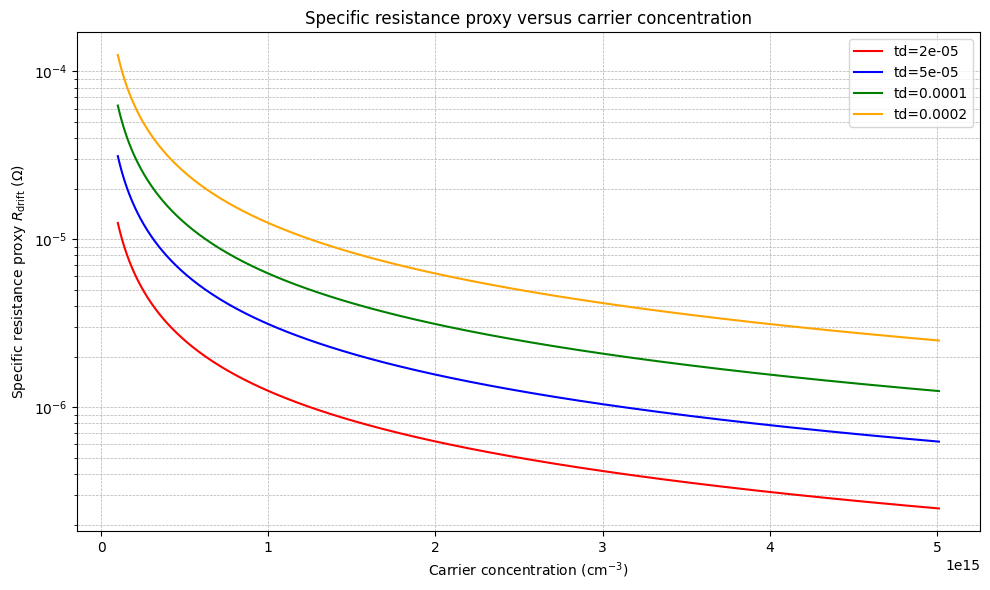

In [2]:
# Subtask 2.1.5 Plot R_drift versus N_D for the selected t_d

if __name__ == "__main__":
    # Generate the plot
    plt.figure(figsize=(10, 6))
    for i, act_t_d in enumerate(t_d_parameter):
        # Calculate result
        R_drift = get_R_drift(ND_plot, act_t_d)
        # Create legend per result
        text=f"td={act_t_d}"
        plt.semilogy(ND_plot/1e6, R_drift, label=text, color=color_list[i])
    # Put legend to upper left
    plt.legend(loc='upper left')
    plt.xlabel(r'Carrier concentration (cm$^{-3}$)')
    plt.ylabel(r'Specific resistance proxy $R_{\mathrm{drift}}$ ($\Omega$)')
    plt.title("Specific resistance proxy versus carrier concentration")
    # plt.title('R_ versus drift length')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show() 

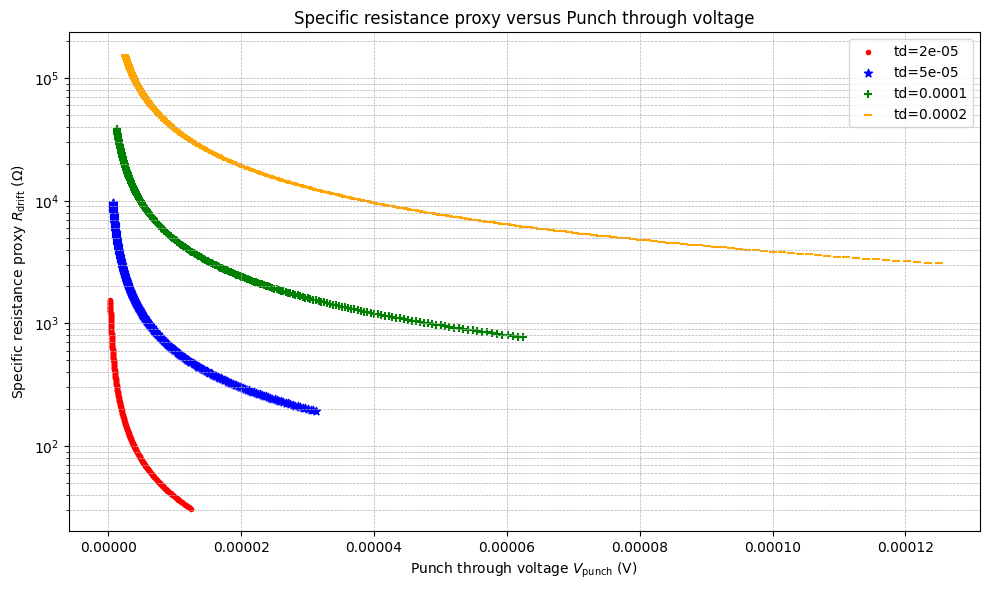

In [3]:
# Subtask 2.1.6 Create a scatter plot of ""V_PT versus R_drift""

if __name__ == "__main__":
    # Generate the plot
    plt.figure(figsize=(10, 6))
    for i, act_t_d in enumerate(t_d_parameter):
        v_punch_t_d = get_v_punch(ND_plot, act_t_d)
        # Calculate result
        R_drift = get_R_drift(ND_plot, act_t_d)
        # Create legend per result
        text=f"td={act_t_d}"
        plt.scatter(R_drift, v_punch_t_d, label=text, color=color_list[i], marker=marker_list[i])
    # y-Achse logarithmis setzen
    plt.yscale('log')
    # Put legend to upper left
    plt.legend(loc='upper left')
    plt.xlabel(r'Punch through voltage $V_{\mathrm{punch}}$ (V)')
    plt.ylabel(r'Specific resistance proxy $R_{\mathrm{drift}}$ ($\Omega$)')
    plt.title("Specific resistance proxy versus Punch through voltage")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show() 

## 2.2 Charge-controlled switching penalty in a power BJT

Visualize why stored charge makes BJT turn-off difficult.
For a simplified model we assume that the total removable stored charge is:
$$Q_{\mathrm{tot}} =  Q_\mathrm{s} + \Delta Q.$$
where $Q_\mathrm{s}$ is charge at edge of saturation and $\Delta Q$ is additional deep-saturation charge.

Use following parameters:
- $Q_\mathrm{s} = 28\mathrm{\mu  C}$
- $V_\mathrm{CC} = 300\mathrm{V}$
- $I_\mathrm{C} = 30\mathrm{A}$
- $\Delta Q_\mathrm{s} = 0~\mathrm{\mu C}, 10~\mathrm{\mu }, 20~\mathrm{\mu C} and 30~\mathrm{\mu C}$
- Reverse base current values: $I_{\mathrm{B,{rev}}} = 2~\mathrm{A}, 4~\mathrm{A} and 6~\mathrm{A}$

2.2.1 Add constant variables for the constant values.

2.2.2 Create a function with input parameter  $\Delta Q$, which calculates total charge $Q_{\mathrm{tot}}$.

2.2.3 Create a function with input parameters  $Q_{\mathrm{tot}}$ and $I_{\mathrm{B, ref}}$, which calculates  storage time  $t_\mathrm{s}$ based on equation
$$t_\mathrm{s} =  \frac{Q_{\mathrm{tot}}}{I_{\mathrm{B},\mathrm{rev}}}.$$

2.2.4 Create a function with input parameter  $t_\mathrm{s}$, which calculates  switch loss energy  $E_{\mathrm{off}}$ (approximation) based on equation
$$E_{\mathrm{off}} =  V_\mathrm{CC} I_\mathrm{C} \cdot t_\mathrm{s}.$$

2.2.5 Plot $t_{\mathrm{s}}$ versus $\Delta Q_\mathrm{s}$ for the three reverse-base currents.

2.2.6 Plot the turn-off energy proxy $E_{\mathrm{off}}$ versus $\Delta Q_\mathrm{s}$ for the three reverse-base currents.

2.2.7 Plot $t_{\mathrm{s}}$ versus $I_{\mathrm{B,rev}}$ for $\Delta Q_\mathrm{s}= 20~\mathrm{\mu C}$.

2.2.8 Comment on the design question: "Is it always beneficial to drive a BJT deeper into saturation?"


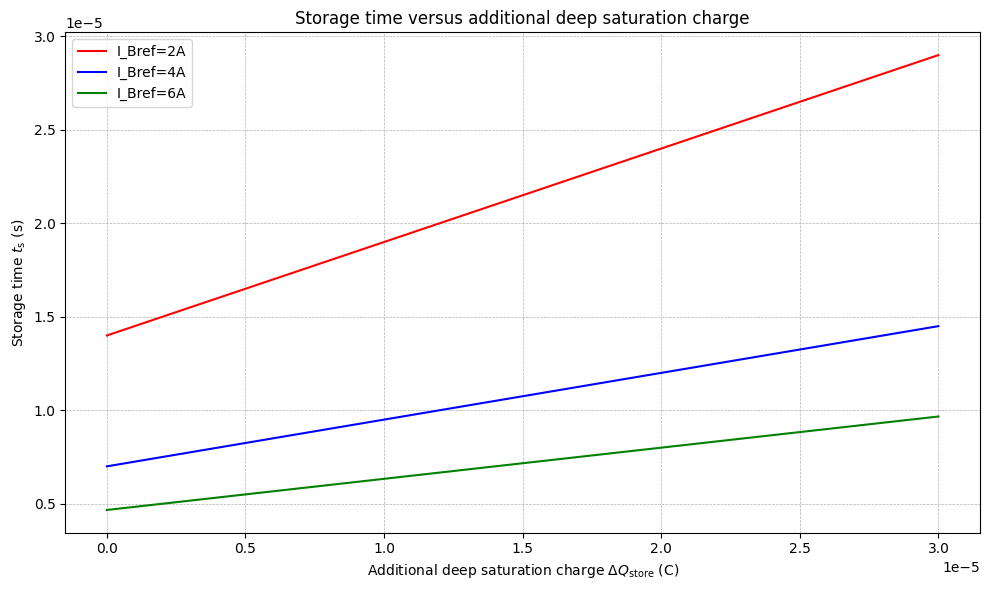

In [4]:
# Subtask 2.2.1 Add constant variables for the constant values.

# ---------------------------------------------------------------------
# Fixed constants for the tutorial
# ---------------------------------------------------------------------
Q_store = 28e-6          # 28e-6 C
V_CC = 300               # 300 V
I_C = 30                 # 30 A

I_Brev_parameter = np.array([2, 4, 6])                  # List with 2A, 4A, 6A
dQ_store = np.array([0, 10e-6, 20e-6, 30e-6])           # List with 0, 10e-6C, 20e-6C, 30e-6C

# Subtask 2.2.2 Create a function with input parameter  Delta Q_store, which calculates total charge Q_tot.

# Calculate total charge: Q_tot = Q_store + dQ_store
def get_Q_tot(act_dQ_store):
    return Q_store + act_dQ_store

# Subtask 2.2.3 Create a function with input parameters Q_tot and I_B,ref, which calculates  storage time  t_s.

# Calculate total charge: t_s= Q_tot/I_C
def get_t_s(act_Q_tot, act_I_C):
    return act_Q_tot/act_I_C

# Subtask 2.2.4 Create a function with input parameter  t_s, which calculates  switch loss energy  E_off (approximation).

# Calculate the approximated switch loss energy E_off = V_CC*I_CC*t_s
def get_E_off(act_V_CC, act_I_C, act_t_s):
    return act_V_CC * act_I_C * act_t_s

if __name__ == "__main__":
    # Subtask 2.2.5 Plot t_s versus dQ_store for the three reverse-base currents.

    # Calculate the total charge
    Q_tot=get_Q_tot(dQ_store)

    # Generate the plot
    plt.figure(figsize=(10, 6))
    for i, act_I_Brev in enumerate(I_Brev_parameter):
        # Calculate the storage time for each reverse-base current
        t_store = get_t_s(Q_tot, act_I_Brev)
        # Create legend per result
        text=f"I_Bref={act_I_Brev}A"
        plt.plot(dQ_store, t_store, label=text, color=color_list[i])
    # Put legend to upper left
    plt.legend(loc='upper left')
    plt.xlabel(r'Additional deep saturation charge $\Delta Q_{\mathrm{store}}$ (C)')
    plt.ylabel(r'Storage time $t_{\mathrm{s}}$ (s)')
    plt.title("Storage time versus additional deep saturation charge")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show() 

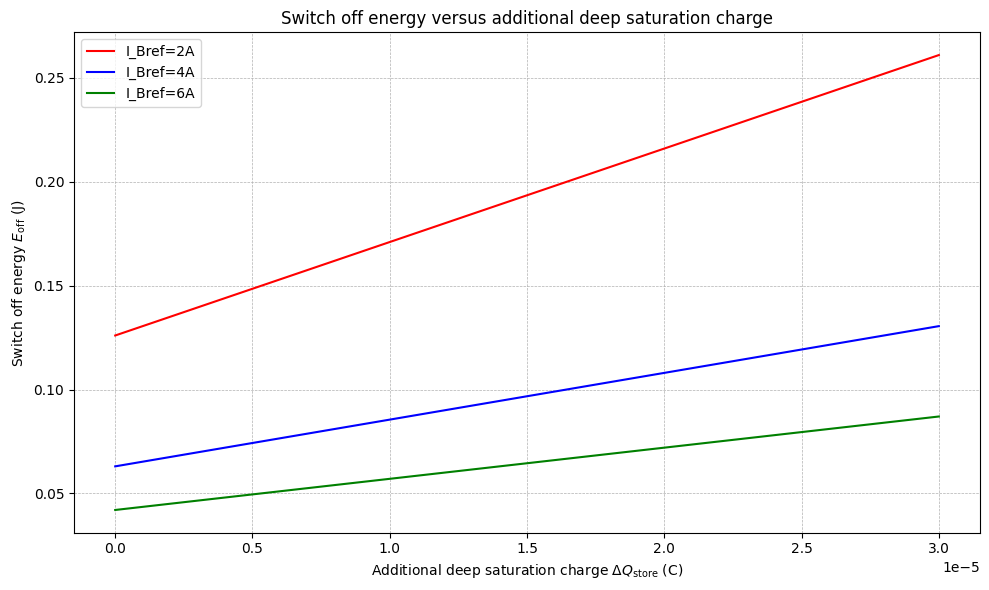

In [5]:
if __name__ == "__main__":
    # Subtask 2.2.6 Plot the turn-off energy proxy E_off versus dQ_store for the three reverse-base currents.

    # Calculate the total charge
    Q_tot=get_Q_tot(dQ_store)
 
    # Generate the plot
    plt.figure(figsize=(10, 6))
    for i, act_I_Brev in enumerate(I_Brev_parameter):
        # Calculate the storage time for each reverse-base current
        t_store = get_t_s(Q_tot, act_I_Brev)        
        # Calculate the storage time for each reverse-base current
        E_off = get_E_off(V_CC, I_C, t_store)
        # Create legend per result
        text=f"I_Bref={act_I_Brev}A"
        plt.plot(dQ_store, E_off, label=text, color=color_list[i])
    # Put legend to upper left
    plt.legend(loc='upper left')
    plt.xlabel(r'Additional deep saturation charge $\Delta Q_{\mathrm{store}}$ (C)')
    plt.ylabel(r'Switch off energy $E_{\mathrm{off}}$ (J)')
    plt.title("Switch off energy versus additional deep saturation charge")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show() 

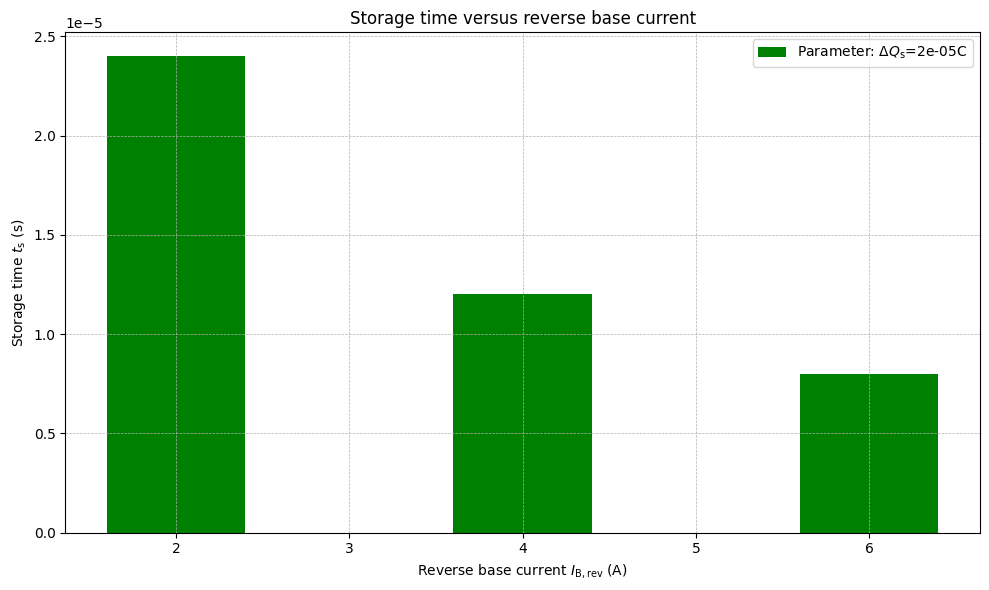

In [6]:
if __name__ == "__main__":
    # Subtask 2.2.7 Plot t_s versus I_Brev for dQ_store = 20e-6C.

    # Set the additional deep saturation charge
    dQ_store_exp = 20e-6

    # Calculate the total charge
    Q_tot=get_Q_tot(dQ_store_exp)

    # Generate the plot
    plt.figure(figsize=(10, 6))

    # Calculate the storage time dependend on reverse-base current
    t_store = get_t_s(Q_tot, I_Brev_parameter)        
    # Create legend
    text= r"Parameter: $\Delta Q_\mathrm{s}$" +  f"={dQ_store_exp}C"
    plt.bar(I_Brev_parameter, t_store, label=text, color='green')
    # Put legend to upper left
    plt.legend(loc='upper left')
    plt.xlabel(r'Reverse base current $I_{\mathrm{B,{rev}}}$ (A)')
    plt.ylabel(r'Storage time $t_{\mathrm{s}}$ (s)')
    plt.title("Storage time versus reverse base current")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show() 

## 2.2.8 Answer of question: "Is it always beneficial to drive a BJT deeper into saturation?"
This isn't the case, because deeper saturation may reduce instantaneous $V_\mathrm{CE}$ in the ON-state, but it can substantially increase stored charge
and therefore turn-off loss. This matches the lecture sequence on $Q_\mathrm{b}$, $Q_\mathrm{ce}$, $Q_\mathrm{cb}$, turn-on/turn-off dynamics, and SOA
constraints.